<a href="https://colab.research.google.com/github/blueberrycrumble/AIFFEL_quest_cr/blob/master/DLThon_jellyfish_dataCleanup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DL톤 해파리 분류기
아이펠 코어 12기 팀: 해파리지앵  
@author: Hyeseung Lee  
Created: 2025-04-01  

## Introduction

## 0. 데이터셋 준비

In [ ]:
# 캐글 API 키로 로그인
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
# 데이터셋을 다운로드해서 캐시에 저장
kagglehub.dataset_download('anshtanwar/jellyfish-types')

100%|██████████| 25.5M/25.5M [00:01<00:00, 15.9MB/s]

Extracting files...


'/root/.cache/kagglehub/datasets/anshtanwar/jellyfish-types/versions/16'

In [ ]:
# 원본 데이터셋 경로와 구글 드라이브 경로
source_path = "/root/.cache/kagglehub/datasets/anshtanwar/jellyfish-types/versions/16"
target_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset"

# 절대 경로 설정
data_path = os.path.join(source_path, "Train_Test_Valid")
!mkdir -p "{target_path}"

# 필요한 폴더만 복사
if os.path.exists(data_path):
    !cp -r "{data_path}" "{target_path}/"
    print(f"Train_Test_Valid 폴더만 복사 완료")
else:
    print(f"{data_path} 폴더가 원본에 존재하지 않습니다.")

# 경로 내 파일 확인
files = os.listdir(data_path)
!ls -la {target_path}
print(files)

Train_Test_Valid 폴더만 복사 완료
total 16
drwx------ 5 root root 4096 Apr  3 04:52 Clean_dataset
drwx------ 2 root root 4096 Apr  2 14:24 ext_dataset
drwx------ 2 root root 4096 Apr  2 16:34 .ipynb_checkpoints
drwx------ 5 root root 4096 Apr  3 04:53 Train_Test_Valid
['Train', 'valid', 'test']




---



## 1. EDA

In [ ]:
import pandas as pd
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from tqdm import tqdm
import warnings
from PIL import Image
import random
import glob
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

In [ ]:
# 원본 데이터셋의 경로 설정
data_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid"
train_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/Train"
val_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/valid"
test_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/test"

# 클린 데이터셋의 경로 설정
clean_data_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Clean_dataset"
clean_train_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Clean_dataset/Train"
clean_val_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Clean_dataset/valid"
clean_test_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Clean_dataset/test"

print(f"원본 데이터셋 경로:")
print(train_path)
print(val_path)
print(test_path)
print()
print(f"클린 데이터셋 경로:")
print(clean_train_path)
print(clean_val_path)
print(clean_test_path)

원본 데이터셋 경로:
/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/Train
/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/valid
/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Train_Test_Valid/test

클린 데이터셋 경로:
/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Clean_dataset/Train
/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Clean_dataset/valid
/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Clean_dataset/test


In [ ]:
def count_images_per_class(folder_path):
    """
    특정 폴더 내의 클래스별 이미지 개수를 셉니다.

    Args:
        folder_path: 이미지가 있는 폴더 경로

    Returns:
        클래스별 이미지 개수를 담은 딕셔너리
    """
    class_counts = {}
    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        if os.path.isdir(class_folder):
            class_counts[class_name] = len(os.listdir(class_folder))
    return class_counts

# train_path와 val_path에서 클래스별 이미지 개수 세기
train_counts = count_images_per_class(clean_train_path)
val_counts = count_images_per_class(clean_val_path)
test_counts = count_images_per_class(clean_test_path)
# 데이터프레임 생성
df = pd.DataFrame({'train': train_counts, 'val': val_counts, 'test': test_counts})

# NaN 값을 0으로 채우기
df = df.fillna(0).astype(int)

# 결과 출력
print(f"원본 이미지 개수:\n{df}")

원본 이미지 개수:
                         train  val  test
Moon_jellyfish              77   20     6
barrel_jellyfish            77   20     5
blue_jellyfish              72   18     7
compass_jellyfish           77   20     7
lions_mane_jellyfish        77   20     8
mauve_stinger_jellyfish     77   20     7


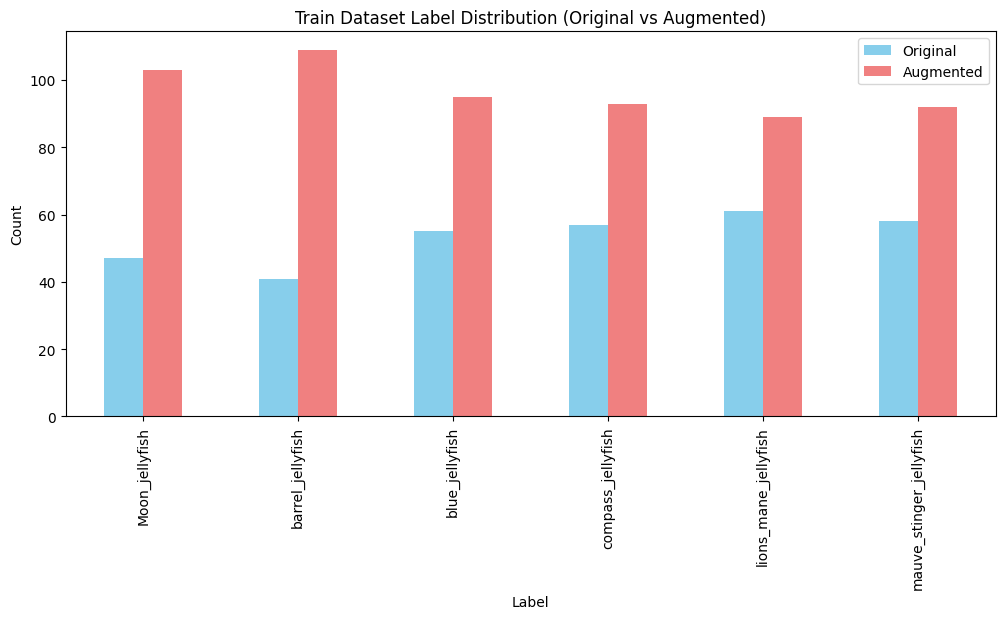

In [ ]:
# 원본 이미지의 라벨 분포 확인 (Augmentation 데이터와 원본 이미지 구분)
def count_labels(dataset_path):
    label_counts = {}
    for folder in os.listdir(dataset_path):
        folder_path = os.path.join(dataset_path, folder)
        if os.path.isdir(folder_path):
            # 폴더 내 이미지 파일 확인
            original_count = 0
            augmented_count = 0
            for filename in os.listdir(folder_path):
                if filename.startswith("aug-"):
                    augmented_count += 1
                else:
                    original_count += 1
            # 라벨별 original, augmented 개수 저장
            label_counts[folder] = {"Original": original_count, "Augmented": augmented_count}
    return label_counts

# Train 라벨 개수 집계
train_counts = count_labels(train_path)

# 데이터프레임 변환
df_train = pd.DataFrame.from_dict(train_counts, orient='index')
df_train = df_train.reset_index().rename(columns={"index": "Label"})

# 라벨 분포 시각화 (Original vs Augmented)
fig, ax = plt.subplots(figsize=(12, 5))
df_train.plot(kind="bar", x="Label", y=["Original", "Augmented"], ax=ax, color=["skyblue", "lightcoral"])
ax.set_title("Train Dataset Label Distribution (Original vs Augmented)")
ax.set_ylabel("Count")
plt.show()

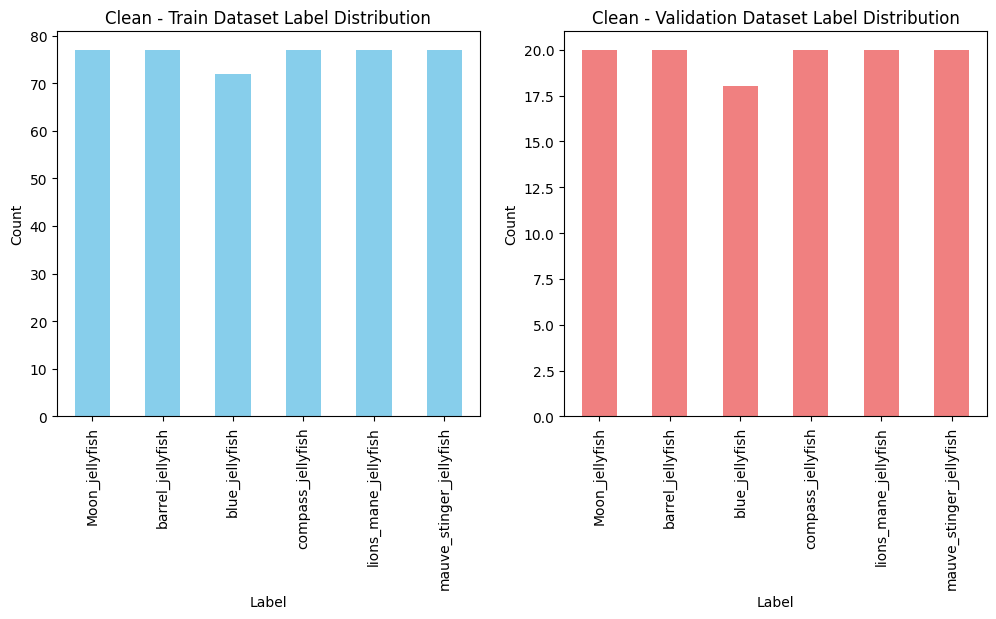

In [ ]:
# 라벨 분포 확인
def count_labels(dataset_path):
    label_counts = {}
    for folder in os.listdir(dataset_path):
        # dataset_path를 사용하여 폴더 경로 생성
        folder_path = os.path.join(dataset_path, folder)
        if os.path.isdir(folder_path):  # 폴더인지 확인
            label_counts[folder] = int(len(os.listdir(folder_path)))  # 해당 폴더 내 파일 개수 저장
    return label_counts

# Train & Validation 라벨 개수 집계
train_counts = count_labels(clean_train_path)
val_counts = count_labels(clean_val_path)

# 데이터프레임 변환
df_train = pd.DataFrame(list(train_counts.items()), columns=["Label", "Count"])
df_val = pd.DataFrame(list(val_counts.items()), columns=["Label", "Count"])

# 라벨 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_train.plot(kind="bar", x="Label", y="Count", ax=axes[0], color="skyblue", legend=False)
axes[0].set_title("Clean - Train Dataset Label Distribution")
axes[0].set_ylabel("Count")

df_val.plot(kind="bar", x="Label", y="Count", ax=axes[1], color="lightcoral", legend=False)
axes[1].set_title("Clean - Validation Dataset Label Distribution")
axes[1].set_ylabel("Count")

plt.show()

In [ ]:
def get_class_labels(data_path):
  """
  디렉토리 구조를 기반으로 클래스 레이블 추론

  Args:
    data_path: 클래스 별 하위폴더를 포함하는 데이터셋의 상위 디렉토리

  Returns:
    클래스 레이블을 딕셔너리로 반환
  """
  class_labels = {}
  for folder_name in os.listdir(data_path):
    folder_path = os.path.join(data_path, folder_name)
    if os.path.isdir(folder_path):
      class_labels[folder_name] = folder_name  # Assuming directory name is the class label
  return class_labels

# Get class labels for train and validation sets
clean_train_labels = get_class_labels(clean_train_path)
clean_val_labels = get_class_labels(clean_val_path)

print("Train Labels:", clean_train_labels)
print("Validation Labels:", clean_val_labels)

Train Labels: {'Moon_jellyfish': 'Moon_jellyfish', 'barrel_jellyfish': 'barrel_jellyfish', 'blue_jellyfish': 'blue_jellyfish', 'compass_jellyfish': 'compass_jellyfish', 'lions_mane_jellyfish': 'lions_mane_jellyfish', 'mauve_stinger_jellyfish': 'mauve_stinger_jellyfish'}
Validation Labels: {'Moon_jellyfish': 'Moon_jellyfish', 'barrel_jellyfish': 'barrel_jellyfish', 'blue_jellyfish': 'blue_jellyfish', 'compass_jellyfish': 'compass_jellyfish', 'lions_mane_jellyfish': 'lions_mane_jellyfish', 'mauve_stinger_jellyfish': 'mauve_stinger_jellyfish'}


In [ ]:
def get_one_image_per_class(data_path, class_labels):
  """
  Extracts one image per class from the data directory.

  Args:
    data_path: Path to the data directory.
    class_labels: A dictionary mapping class labels to directory names.

  Returns:
    A dictionary mapping class labels to the path of a single image for that class.
  """
  one_image_per_class = {}
  for class_label, dir_name in class_labels.items():
    class_dir = os.path.join(data_path, dir_name)
    image_files = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    if image_files:  # Check if there are any images in the class directory
      one_image_per_class[class_label] = os.path.join(class_dir, random.choice(image_files))
  return one_image_per_class

# Get one image per class from the training data
one_image_per_class_train = get_one_image_per_class(clean_train_path, clean_train_labels)

print("One Image per Class (Train):", one_image_per_class_train)

One Image per Class (Train): {'Moon_jellyfish': '/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Clean_dataset/Train/Moon_jellyfish/Aurelia_aurita_01.jpg', 'barrel_jellyfish': '/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Clean_dataset/Train/barrel_jellyfish/Me╠üduse_(Rhizostoma_pulmo)_en_mer_Noire_(Ifremer_00798-91034_-_51995).jpg', 'blue_jellyfish': '/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Clean_dataset/Train/blue_jellyfish/Blue_jellyfish_in_Brofjorden_at_Sandvik_59.jpg', 'compass_jellyfish': '/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Clean_dataset/Train/compass_jellyfish/19.jpg', 'lions_mane_jellyfish': "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Clean_dataset/Train/lions_mane_jellyfish/Lion's_Mane_Jelly_(Cyanea_capillata)_-_Sandnes,_Norway_2021-08-02_(01).jpg", 'mauve_stinger_jellyfish': '/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/Clean

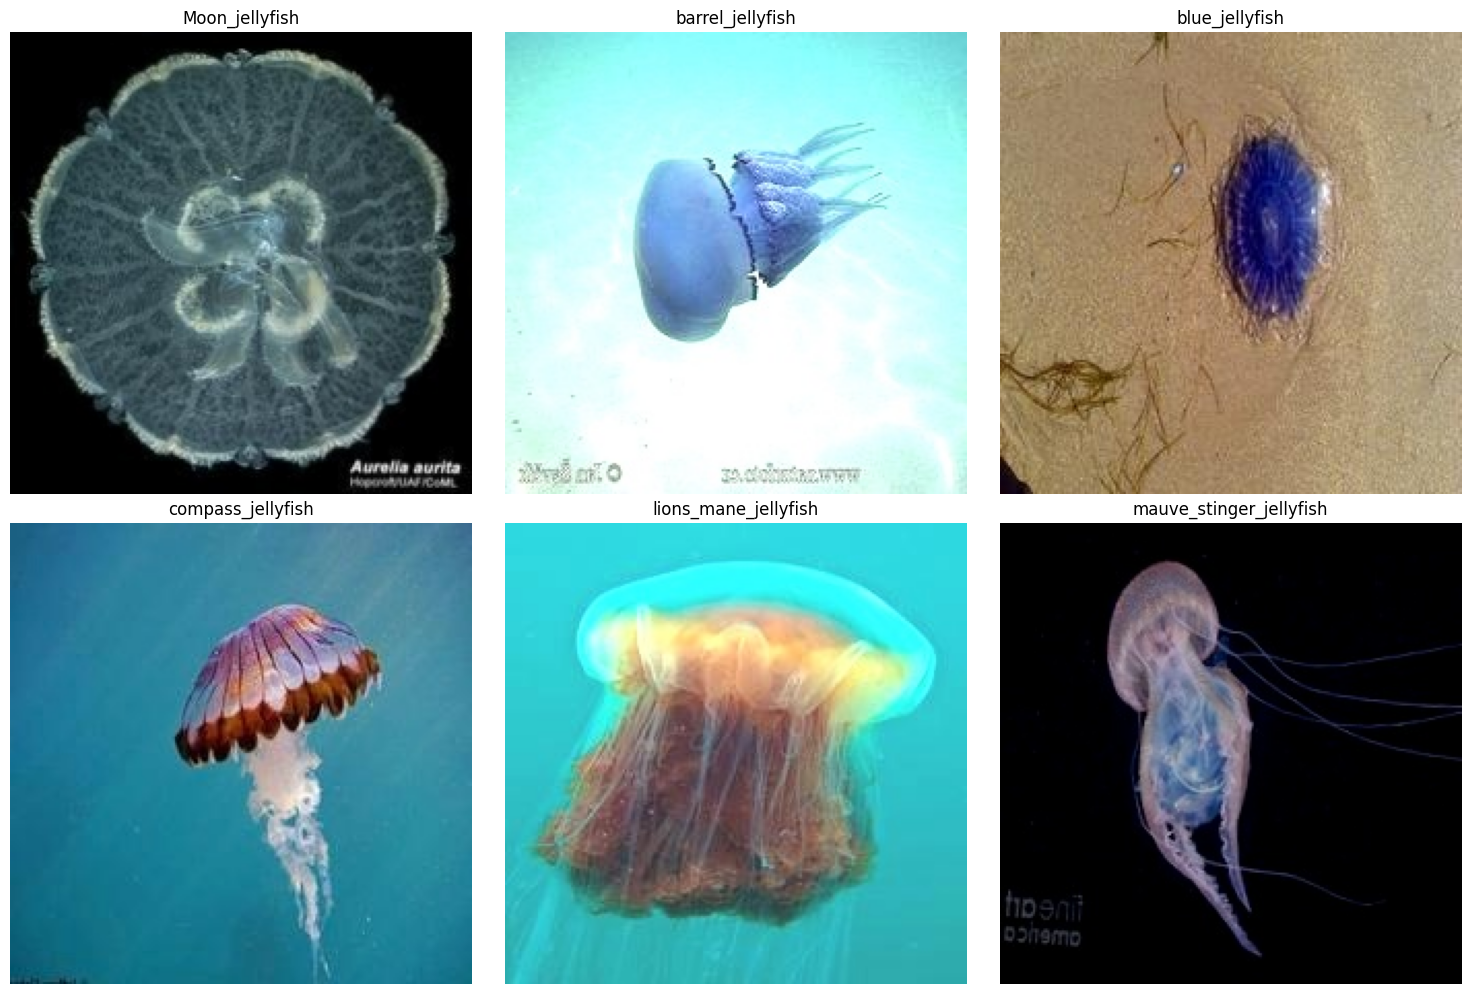

In [ ]:
# 실행시 마다 해당 클래스에서 이미지 랜덤 출력
class_labels = list(clean_train_labels.keys())

num_classes = len(class_labels)
num_cols = 3
num_rows = (num_classes + num_cols - 1) // num_cols

plt.figure(figsize=(15, 5 * num_rows))

for i, class_label in enumerate(class_labels):
    class_dir = os.path.join(train_path, class_label)
    image_files = [f for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

    image_file = random.choice(image_files)
    image_path = os.path.join(class_dir, image_file)

    img = mpimg.imread(image_path)
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(img)
    plt.title(f"{class_label}")  # 라벨 출력
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# def split_dataset(merged_dataset_path, train_path, val_path, test_size=0.2):
#     """
#     merged_dataset을 클래스별로 균등하게 훈련 데이터와 검증 데이터로 분할합니다.

#     Args:
#         merged_dataset_path: 병합된 데이터셋 경로
#         train_path: 훈련 데이터셋을 저장할 경로
#         val_path: 검증 데이터셋을 저장할 경로
#         test_size: 검증 데이터셋 비율 (기본값: 0.2)
#     """

#     os.makedirs(train_path, exist_ok=True)
#     os.makedirs(val_path, exist_ok=True)

#     for class_name in os.listdir(merged_dataset_path):
#         class_dir = os.path.join(merged_dataset_path, class_name)
#         if os.path.isdir(class_dir):
#             images = [img for img in os.listdir(class_dir) if img.lower().endswith(('.png', '.jpg', '.jpeg','.JPG'))] # Add JPG to support upper case extensions
#             print(f"Class: {class_name}, Images: {images}") # Debugging print statement
#             print(f"Number of images in {class_name}: {len(images)}") # Print the number of images found

#             # Check if images list is empty before proceeding
#             if len(images) == 0:
#                 print(f"Warning: No images found in {class_dir} with specified extensions. Skipping this class.")
#                 continue

#             train_images, val_images = train_test_split(images, test_size=test_size, random_state=42)  # random_state for reproducibility

#             # Create class subdirectories in train and val paths
#             train_class_dir = os.path.join(train_path, class_name)
#             val_class_dir = os.path.join(val_path, class_name)
#             os.makedirs(train_class_dir, exist_ok=True)
#             os.makedirs(val_class_dir, exist_ok=True)

#             # Copy images to respective directories
#             for image in train_images:
#                 source_path = os.path.join(class_dir, image)
#                 destination_path = os.path.join(train_class_dir, image)
#                 shutil.copy2(source_path, destination_path)  # copy2 to preserve metadata

#             for image in val_images:
#                 source_path = os.path.join(class_dir, image)
#                 destination_path = os.path.join(val_class_dir, image)
#                 shutil.copy2(source_path, destination_path)


# # 경로 설정 (실제 경로로 변경해야 함)
# merged_data_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/merged_dataset"
# new_train_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/merged_dataset/Train"
# new_val_path = "/content/drive/MyDrive/ColabNotebooks/ToyDatasets/jellyfish-dataset/merged_dataset/valid"

# # 데이터셋 분할
# split_dataset(merged_data_path, new_train_path, new_val_path)


Class: Moon_jellyfish, Images: ['36.jpg', '30.jpg', '35.jpg', '29.JPG', '45.jpg', '16.jpg', '12.jpg', '56.jpg', '41.jpg', '31.jpg', '61.jpg', '53.jpg', '38.jpg', '05.jpg', '22.jpg', '03.jpg', '46.jpg', '43.jpg', '54.jpg', '04.jpg', '13.jpg', '47.jpg', '50.jpg', '21.jpg', '28.jpg', '18.jpg', '40.jpg', '01.jpg', '42.jpg', '26.jpg', '24.jpg', '55.jpg', '02.jpg', '17.jpg', '06.jpg', '14.jpg', '49.jpg', '08.jpg', '57.jpg', '58.jpg', '10.jpg', '52.JPG', '60.jpg', '20.jpg', '15.jpg', '44.jpg', '27.jpg', '09.jpg', 'jane-ta-oss48ywQ2VQ-unsplash.jpg', 'jonathan-diemel-vQvq16ZQM60-unsplash.jpg', 'Moon_jellyfishes_and_sea_gooseberry_in_Sandvik_2.jpg', 'Common_Moon_Jelly_(Aurelia_aurita)_-_B├ªrum,_Norway_2022-05-15_(03).jpg', 'Aurelia-aurita-3_(cropped).jpg', '180px-Moon_jellyfish_at_Govik_beach_4.jpg', 'Med_-_Aurelia_aurita_-_10.jpg', 'Cnidaria_disturbing_the_pycnocline_in_Gullmarn_fjord_at_Sa╠êmstad_4.jpg', 'Two_beached_moon_jellyfishes_in_Holla╠êndaro╠êd_2.jpg', 'Aurelia_aurita_(auge24eu).jpg

In [85]:
def load_dataset_from_directory(directory, img_size=(224, 224), batch_size=32, flatten=False):
    """폴더에서 RGB 이미지 데이터셋을 로드하는 함수 (최신 TensorFlow 방식)"""
    dataset = tf.keras.utils.image_dataset_from_directory(
        directory,
        image_size=img_size,
        batch_size=batch_size,
        color_mode='rgb',
        shuffle=True,
        seed=42,
        labels='inferred',
        label_mode='int'
    )

    # 클래스 이름 가져오기
    class_names = dataset.class_names
    class_dict = {class_name: i for i, class_name in enumerate(class_names)}

    # 데이터셋 전처리 (정규화)
    def preprocess(images, labels):
        images = tf.cast(images, tf.float32) / 255.0
        return images, labels

    dataset = dataset.map(preprocess)

    # 전체 데이터 메모리에 로드
    X_list = []
    y_list = []

    for images, labels in dataset:
        X_list.append(images.numpy())
        y_list.append(labels.numpy())

    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)

    # 필요한 경우 평탄화(flatten)
    if flatten:
        X = X.reshape(X.shape[0], -1)  # (n_samples, height*width*channels)

    # 그레이스케일 특화 코드
    # 기존: elif color_mode == 'grayscale': X = X[..., 0]

    return X, y, class_dict



In [86]:
# Assuming clean_train_path is defined as in the previous code
X_train, y_train, class_dict = load_dataset_from_directory(clean_train_path, flatten=False)
print(X_train.shape, y_train.shape)


Found 457 files belonging to 6 classes.
(457, 224, 224, 3) (457,)


In [ ]:
# 이미지 증강 모듈 깃허브에서 불러오기
!curl -O https://raw.githubusercontent.com/blueberrycrumble/AIFFEL_quest_cr/refs/heads/master/DLthon/img_augmentation.py

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 21114  100 21114    0     0  34387      0 --:--:-- --:--:-- --:--:-- 34387


In [ ]:
# 방금 구현한 데이터 증강 모듈 임포트
# 파일로 저장한 경우 import 경로를 적절히 수정
from img_augmentation import (
    apply_augmentation, SaltAndPepperNoise, GaussianNoise,
    RandomAffine, RandomFlip, RandomBrightness, RandomContrast,
    GaussianBlur, SequentialAugmentation, RandomChoice, RandomApply,
    ImageDataset
)

In [87]:
img_size = (224, 224)  # 일반적인 CNN 입력 크기
# 데이터 로드
X_train, y_train, class_dict = load_dataset_from_directory(clean_train_path, img_size=img_size)
X_test, y_test, _ = load_dataset_from_directory(clean_test_path, img_size=img_size)
X_valid, y_valid, _ = load_dataset_from_directory(clean_val_path, img_size=img_size)

# 데이터 정보 출력
print(f"클래스 정보: {class_dict}")
print(f"훈련 데이터: {X_train.shape}, {y_train.shape}")
print(f"테스트 데이터: {X_test.shape}, {y_test.shape}")
print(f"검증 데이터: {X_valid.shape}, {y_valid.shape}")

Found 457 files belonging to 6 classes.
Found 40 files belonging to 6 classes.
Found 118 files belonging to 6 classes.
클래스 정보: {'Moon_jellyfish': 0, 'barrel_jellyfish': 1, 'blue_jellyfish': 2, 'compass_jellyfish': 3, 'lions_mane_jellyfish': 4, 'mauve_stinger_jellyfish': 5}
훈련 데이터: (457, 224, 224, 3), (457,)
테스트 데이터: (40, 224, 224, 3), (40,)
검증 데이터: (118, 224, 224, 3), (118,)


In [84]:
def apply_augmentation(image, augmentation_transforms, num_samples=5):
    """
    하나의 이미지 원본에 대한 여러장의 증강 이미지를 생성하는 함수 (인라인 버전)
    """
    if num_samples <= 0:
        raise ValueError(f"num_samples must be positive, got {num_samples}")

    # 이미지 처리
    if isinstance(image, np.ndarray):
        # 데이터 타입 정규화
        if image.dtype == np.uint8:
            image = image.astype(np.float32) / 255.0
        elif image.dtype not in (np.float32, np.float64):
            raise ValueError(f"Unsupported dtype: {image.dtype}")
        else:
            image = image.astype(np.float32)

        # 텐서로 변환
        # image_tensor = tf.convert_to_tensor(image, dtype=tf.float32)


    # 증강 이미지 생성
    augmented_images = []
    for _ in range(num_samples):
        # 증강 적용
        aug_tensor = augmentation_transforms(tf.identity(image))

        # 배치 차원 제거하여 이미지로 변환
        aug_image = aug_tensor.numpy()[0]

        augmented_images.append(aug_image)

    return augmented_images

def visualize_augmentations_direct(image, augmentation_transforms, num_samples=24):
    """
    원본 이미지와 증강된 이미지들을 시각화하는 함수 (인라인 버전)
    """
    # 증강 이미지 생성
    augs = apply_augmentation(image, augmentation_transforms, num_samples=num_samples)

    # 행과 열 계산 (원본 포함)
    n_total = min(num_samples + 1, 25)  # 최대 25개 (5x5 그리드)
    n_cols = 5
    n_rows = (n_total + n_cols - 1) // n_cols

    # 시각화
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 12))
    fig.suptitle('원본 이미지와 증강된 이미지들')

    for i, ax in enumerate(axes.flatten()):
        ax.axis('off')
        if i == 0:
            ax.imshow(image)
            ax.set_title('원본')
        elif i < n_total:
            ax.imshow(augs[i-1])
        else:
            fig.delaxes(ax)  # 남는 축 제거

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# 직접 정의한 함수 사용
visualize_augmentations(sample_image, augmentation_pipeline, num_samples=24)

InvalidArgumentError: Exception encountered when calling RandomAffine.call().

[1m{{function_node __wrapped__StridedSlice_device_/job:localhost/replica:0/task:0/device:CPU:0}} slice index 2 of dimension 0 out of bounds. [Op:StridedSlice] name: random_affine_6/strided_slice/[0m

Arguments received by RandomAffine.call():
  • inputs=tf.Tensor(shape=(1, 150528), dtype=float32)
  • training=True

In [ ]:
# ImageDataset을 사용한 모델 훈련
def create_model():
    """간단한 CNN 모델 생성"""
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),